# What Readers Love

Goodreads contains more than one million reviews across 13,000+ books. This analysis explores what reader engagement can tell us about book popularity, author reach, reader disagreement, genre engagement, and sustained reader reception.

The analysis focuses on five questions, one per chart below:

- Which books attract the most attention?
- Does publishing more books translate into greater reach for an author?
- Which books generate the strongest disagreement among readers?
- Which genres have the strongest typical engagement?
- Do highly-rated authors sustain strong reception across their published works?

## 1. Understanding the Goodreads Data

In [1]:
import pandas as pd

dictionary = pd.read_csv('../data/goodreads_data_dictionary.csv')
dictionary  # just display it — this is your field reference

,Table,Field,Description
0,works,work_id,Unique identifier for the book (work) in the d...
1,works,isbn,The 10-digit International Standard Book Numbe...
2,works,isbn13,The 13-digit International Standard Book Numbe...
3,works,original_title,"The original title of the book, in its origina..."
4,works,author,Name of the book’s primary author.
5,works,original_publication_year,Year the work was first published.
6,works,num_pages,Total number of pages in the work’s primary ed...
7,works,description,"Summary or synopsis of the book, typically fro..."
8,works,genres,Comma-separated list of genres associated with...
9,works,image_url,URL link to the book’s cover image.


**Observation:** the dictionary confirms `works` is one row per book with pre-aggregated rating counts (`5_star_ratings`...`1_star_ratings`, `ratings_count`, `avg_rating`), while `reviews` is one row per individual review. `work_id` is the shared key between the two tables.

In [2]:
works = pd.read_csv('../data/goodreads_works.csv')

print(works.shape)
works.head()

(13525, 20)


,work_id,isbn,isbn13,original_title,author,original_publication_year,num_pages,description,genres,image_url,reviews_count,text_reviews_count,5_star_ratings,4_star_ratings,3_star_ratings,2_star_ratings,1_star_ratings,ratings_count,avg_rating,similar_books
0,2919130,1416534601,9.781417e+12,Nocturnes,John Connolly,2004.0,NaN,NaN,"fiction, fantasy, paranormal, mystery, thrille...",https://s.gr-assets.com/assets/nophoto/book/11...,8820,338,1118,1601,1029,190,58,3996,3.9,NaN
1,52087333,NaN,NaN,Draw Play,Tia Lewis,2016.0,NaN,Jake:\nI can't believe my coach assigned me a ...,"romance, fiction",https://s.gr-assets.com/assets/nophoto/book/11...,2482,204,204,353,274,77,29,937,3.7,NaN
2,1649583,1416505520,9.781417e+12,Citizen of the Galaxy,Robert A. Heinlein,1957.0,NaN,"In a distant galaxy, the atrocity of slavery w...","fiction, young-adult, fantasy, paranormal, chi...",https://s.gr-assets.com/assets/nophoto/book/11...,16506,447,3539,4351,2863,444,53,11250,4.0,NaN
3,688299,0060541830,9.780061e+12,Congo,Michael Crichton,1980.0,NaN,"Deep in the African rain forest, near the lege...","fiction, mystery, thriller, crime, fantasy, pa...",https://s.gr-assets.com/assets/nophoto/book/11...,170916,1633,25081,45775,48505,14001,2926,136288,3.6,NaN
4,3464264,0451528824,9.780452e+12,Anne of Green Gables,L.M. Montgomery,1908.0,NaN,"Everyone's favorite redhead, the spunky Anne S...","fiction, young-adult, children, history, histo...",https://s.gr-assets.com/assets/nophoto/book/11...,743392,14586,272952,161856,81578,19933,9099,545418,4.2,NaN


**Observation:** 13,525 books, 20 columns. `original_publication_year` loads as `float64` (e.g. `2004.0`) rather than an int — will need casting before any year-based grouping or plotting.

In [3]:
works.dtypes

work_id                        int64
isbn                             str
isbn13                       float64
original_title                   str
author                           str
original_publication_year    float64
num_pages                    float64
description                      str
genres                           str
image_url                        str
reviews_count                  int64
text_reviews_count             int64
5_star_ratings                 int64
4_star_ratings                 int64
3_star_ratings                 int64
2_star_ratings                 int64
1_star_ratings                 int64
ratings_count                  int64
avg_rating                   float64
similar_books                    str
dtype: object

In [4]:
works.isnull().sum()

work_id                         0
isbn                         2051
isbn13                       1661
original_title                  0
author                          0
original_publication_year      18
num_pages                     730
description                   169
genres                          0
image_url                       0
reviews_count                   0
text_reviews_count              0
5_star_ratings                  0
4_star_ratings                  0
3_star_ratings                  0
2_star_ratings                  0
1_star_ratings                  0
ratings_count                   0
avg_rating                      0
similar_books                2515
dtype: int64

**Observation:** the columns that matter most for the five planned charts — `genres`, `author`, `avg_rating`, `ratings_count`, `reviews_count`, the per-star counts — have **zero** missing values. Gaps are concentrated in fields we don't currently plan to chart (`isbn`/`isbn13`, `num_pages`, `description`, `similar_books`), so missingness isn't a blocker for the chart plan.

In [5]:
works.duplicated().sum()

np.int64(0)

**Observation:** no duplicate rows in `works`.

In [6]:
reviews = pd.read_csv('../data/goodreads_reviews.csv')

print(reviews.shape)
reviews.head()
reviews.dtypes
reviews.isnull().sum()

/tmp/ipykernel_49110/1195728872.py:1: DtypeWarning: Columns (3: started_at) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv('../data/goodreads_reviews.csv')


(1143887, 10)


review_id           0
user_id             0
work_id             0
started_at     347495
read_at        112122
date_added          0
rating          37318
review_text         0
n_votes             0
n_comments          0
dtype: int64

**Observation:** 1,143,887 individual reviews. `rating` is missing on 37,318 rows (~3.3%) — these are text-only reviews with no star given, so any per-review rating analysis needs to drop or explicitly account for them. `started_at` triggered a mixed-dtype warning on load and has the most missing values (347,495) — it's the least reliable date field here. Given the file's size (881MB), full loads are workable but slow; may sample for iterative chart development.

In [7]:
works.columns
reviews.columns

Index(['review_id', 'user_id', 'work_id', 'started_at', 'read_at',
       'date_added', 'rating', 'review_text', 'n_votes', 'n_comments'],
      dtype='str')

In [8]:
works['work_id'].isin(reviews['work_id']).mean()  # adjust column name

np.float64(1.0)

**Observation:** every book in `works` has at least one matching review in `reviews` (join coverage = 1.0). Clean key, no orphaned books to worry about when merging the two tables.

### Data preparation decisions

A few modeling decisions were made after inspecting the raw fields, each grounded in a quick check of the data rather than assumption:

- **Author names are effectively single-author entries.** Only 1 of 13,525 records contains a comma in `author`, and it's a pen-name annotation, not a co-author list — so author-level aggregation can group directly on `author`.
- **Genres are multi-valued.** Books carry a median of 6 genre tags (range 1–23), so genre-level analysis treats each (book, genre) pair as its own row — genre totals below are not mutually exclusive.
- **Controversy is measured as the weighted standard deviation of a book's 1–5 star rating distribution**, computed from the `works` star-count columns rather than raw individual review ratings — the star counts are complete for all 13,525 books, while `reviews.rating` is missing on 3.3% of rows.
- **Author trend filter:** to avoid a handful of ratings determining who counts as a "highly-rated author," books needed at least 1,000 ratings and authors needed at least 3 qualifying books. This retained 1,228 authors and 7,859 qualifying books.

## 2. Preparing the Analysis

`works` has two candidate popularity fields — `reviews_count` and `ratings_count`. The controversy metric (weighted std across the five star-count columns) is defined here too, since both are needed before the summary tables can be built.

In [9]:
import numpy as np

star_cols = ['1_star_ratings', '2_star_ratings', '3_star_ratings', '4_star_ratings', '5_star_ratings']
stars = np.array([1, 2, 3, 4, 5])

def weighted_std(row):
    counts = row[star_cols].values.astype(float)
    weights = counts / counts.sum()
    mean = (weights * stars).sum()
    return np.sqrt((weights * (stars - mean) ** 2).sum())

In [10]:
works['star_sum'] = works[star_cols].sum(axis=1)

print("ratings_count == sum(star cols)?", (works['ratings_count'] == works['star_sum']).mean())
print("reviews_count >= ratings_count for what pct of books?", (works['reviews_count'] >= works['ratings_count']).mean())
print()
print((works['reviews_count'] - works['ratings_count']).describe())

ratings_count == sum(star cols)? 1.0
reviews_count >= ratings_count for what pct of books? 0.9997042513863216

count    1.352500e+04
mean     2.522098e+04
std      6.085125e+04
min     -2.590550e+05
25%      3.462000e+03
50%      8.513000e+03
75%      2.124500e+04
max      1.155191e+06
dtype: float64


**Decision: `ratings_count` is the popularity metric used across all charts, not `reviews_count`.**
- `ratings_count` matches the sum of the five star-count columns exactly (100% of rows) — it's fully internally consistent and it's the same denominator used in the controversy metric, so using it everywhere keeps definitions coherent.
- `reviews_count` runs higher on 99.97% of books (it includes text-only reviews with no star given), and on a small number of books it's actually *lower* than `ratings_count` (min diff of −259,055) — an unexplained inconsistency in the source data. `ratings_count` is the safer choice.

### Chart-by-chart definitions

| Chart | Metric | Filter / selection |
|---|---|---|
| 1 — Most popular books | `ratings_count` | top 15 books |
| 2 — Author popularity | `book_count` vs. `total_ratings` per author | all 5,554 authors, no threshold |
| 3 — Controversy | `avg_rating` vs. weighted std | `ratings_count >= 1000` (12,349 books) |
| 4 — Genre engagement | median `ratings_count` per genre | genres exploded, all 16 shown |
| 5 — Sustained reception | `avg_rating` by `original_publication_year` | `ratings_count >= 1000`, ≥3 books/author, top 8 by weighted rating |

In [11]:
genres_exploded = works.assign(genre=works['genres'].str.split(',')).explode('genre')
genres_exploded['genre'] = genres_exploded['genre'].str.strip()
print("Distinct genres:", genres_exploded['genre'].nunique())
genres_exploded['genre'].value_counts()

Distinct genres: 16


genre
fiction               13187
romance                9255
fantasy                7407
paranormal             7407
mystery                6607
thriller               6607
crime                  6607
young-adult            6450
history                3954
historical fiction     3954
biography              3954
children               1297
comics                  961
graphic                 961
non-fiction             601
poetry                  182
Name: count, dtype: int64

### Building the analysis tables

Four tables, one per chart grain, built from the definitions above.

In [12]:
works['rating_std'] = works.apply(weighted_std, axis=1)

book_summary = works[[
    'work_id', 'original_title', 'author', 'original_publication_year',
    'genres', 'ratings_count', 'avg_rating', 'rating_std'
]].copy()

print(book_summary.shape)
book_summary.sort_values('ratings_count', ascending=False).head(3)

(13525, 8)


,work_id,original_title,author,original_publication_year,genres,ratings_count,avg_rating,rating_std
4368,2792775,The Hunger Games,Suzanne Collins,2008.0,"young-adult, fiction, fantasy, paranormal, rom...",5066596,4.3,0.87900
2627,4640799,Harry Potter and the Philosopher's Stone,J.K. Rowling,1997.0,"fantasy, paranormal, young-adult, fiction, chi...",4972886,4.4,0.86698
2652,3212258,Twilight,Stephenie Meyer,2005.0,"young-adult, fantasy, paranormal, fiction, rom...",3992661,3.6,1.36295


**Observation:** `book_summary` covers all 13,525 books, unfiltered — the `ratings_count >= 1000` cut is applied per-chart, not baked in here.

In [13]:
author_summary = works.groupby('author').agg(
    book_count=('work_id', 'count'),
    total_ratings=('ratings_count', 'sum')
).reset_index()

print(author_summary.shape)
author_summary.sort_values('total_ratings', ascending=False).head(5)

(5554, 3)


,author,book_count,total_ratings
2097,J.K. Rowling,12,16814800
5117,Suzanne Collins,8,9310785
5036,Stephenie Meyer,8,8502945
5029,Stephen King,53,7797932
4500,Rick Riordan,24,5874480


**Observation:** J.K. Rowling tops `total_ratings` with only 12 books — an early signal that catalogue size alone won't explain popularity (explored in Chart 2 below).

In [14]:
genre_summary = genres_exploded.groupby('genre').agg(
    median_ratings=('ratings_count', 'median'),
    book_count=('work_id', 'count')
).reset_index().sort_values('median_ratings', ascending=False)

genre_summary

,genre,median_ratings,book_count
10,non-fiction,17359.0,601
12,poetry,15378.5,182
1,children,9413.0,1297
0,biography,8125.0,3954
7,historical fiction,8125.0,3954
8,history,8125.0,3954
5,fiction,7508.0,13187
3,crime,7505.0,6607
14,thriller,7505.0,6607
9,mystery,7505.0,6607


**Observation:** `biography`, `historical fiction`, and `history` share an identical median and book count — those tags heavily co-occur on the same books here, not three independent signals.

In [15]:
qualifying = book_summary[book_summary['ratings_count'] >= 1000].copy()
eligible_authors = qualifying.groupby('author').size()
eligible_authors = eligible_authors[eligible_authors >= 3].index

author_year_summary = qualifying[qualifying['author'].isin(eligible_authors)].copy()
author_year_summary = author_year_summary.dropna(subset=['original_publication_year'])
author_year_summary['original_publication_year'] = author_year_summary['original_publication_year'].astype(int)

print("Final shape:", author_year_summary.shape, "| authors:", author_year_summary['author'].nunique())
author_year_summary.head(3)

Final shape: (7854, 8) | authors: 1228


,work_id,original_title,author,original_publication_year,genres,ratings_count,avg_rating,rating_std
0,2919130,Nocturnes,John Connolly,2004,"fiction, fantasy, paranormal, mystery, thrille...",3996,3.9,0.919003
2,1649583,Citizen of the Galaxy,Robert A. Heinlein,1957,"fiction, young-adult, fantasy, paranormal, chi...",11250,4.0,0.876496
3,688299,Congo,Michael Crichton,1980,"fiction, mystery, thriller, crime, fantasy, pa...",136288,3.6,0.974137


**Observation:** only 5 of 7,859 qualifying rows were missing a publication year; dropping them cost 0 authors — all 1,228 eligible authors still have at least 3 dated books each.

## 3. What Readers Love

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.facecolor': '#fcfcfb',
    'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': '#52514e',
    'text.color': '#0b0b0b',
    'xtick.color': '#52514e',
    'ytick.color': '#52514e',
    'grid.color': '#e5e4de',
    'grid.linewidth': 0.8,
    'font.size': 11,
})

BLUE = '#2a78d6'
CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']

def strip_spines(ax, keep=('bottom',)):
    for side, spine in ax.spines.items():
        spine.set_visible(side in keep)
    ax.set_axisbelow(True)

### 3.1 Which books attract the most attention?

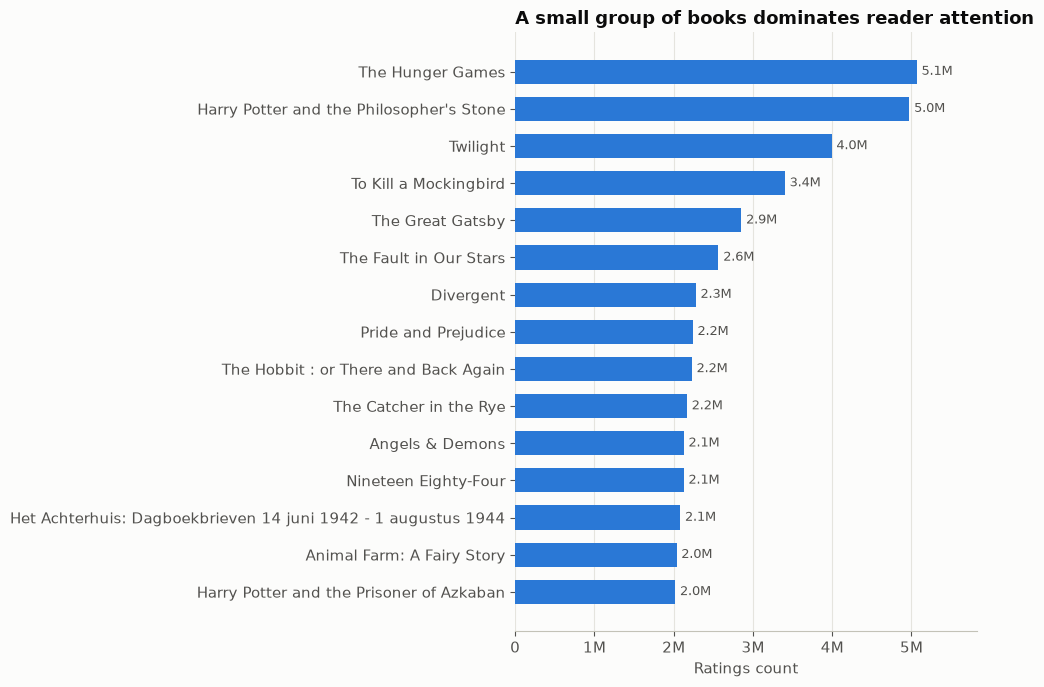

In [17]:
top15 = book_summary.sort_values('ratings_count', ascending=False).head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['original_title'], top15['ratings_count'], color=BLUE, height=0.65)

for bar, value in zip(bars, top15['ratings_count']):
    label = f'{value/1e6:.1f}M' if value >= 1e6 else f'{value:,}'
    ax.text(bar.get_width() + 60000, bar.get_y() + bar.get_height() / 2, label,
             va='center', ha='left', fontsize=9, color='#52514e')

ax.set_xlabel('Ratings count')
ax.set_title('A small group of books dominates reader attention',
              fontsize=13, fontweight='bold', loc='left')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{int(x):,}'))
ax.xaxis.grid(True)
ax.yaxis.grid(False)
strip_spines(ax, keep=('bottom',))
ax.set_xlim(0, top15['ratings_count'].max() * 1.15)
plt.tight_layout()
plt.show()

**Finding:** *The Hunger Games* (5,066,596 ratings) and *Harry Potter and the Philosopher's Stone* (4,972,886) lead by a clear margin — over a million ratings ahead of third-place *Twilight* (3,992,661). The top 15 skews heavily toward YA/crossover fiction (5 of the top 6), but long-standing classics like *To Kill a Mockingbird*, *1984*, and *Pride and Prejudice* still place inside the top 12 — likely reflecting decades of accumulated ratings rather than a recent surge, a distinction raw `ratings_count` can't separate out on its own.

### 3.2 Does publishing more books translate into greater reach for an author?

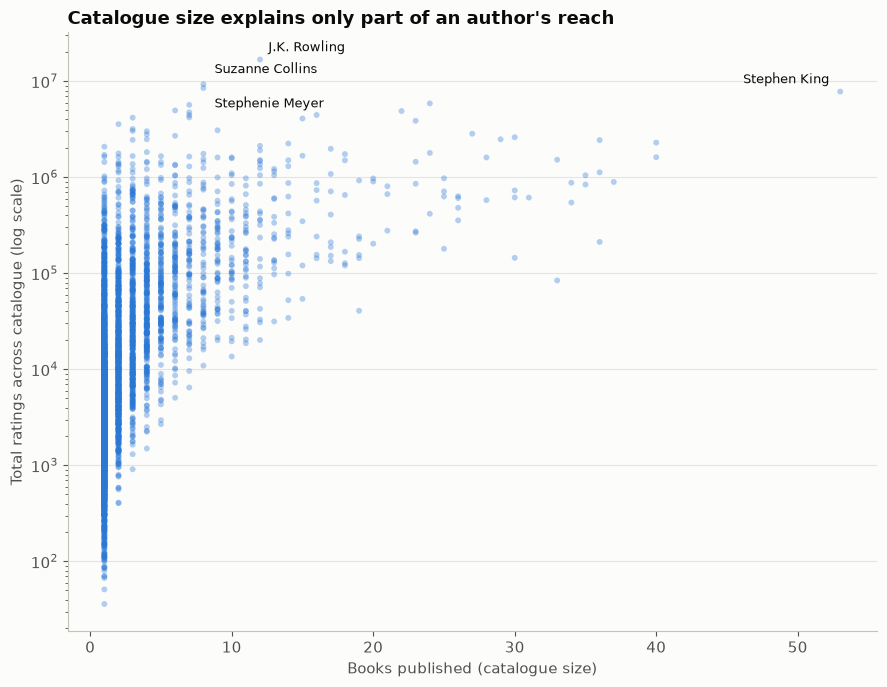

Correlation (book_count, total_ratings): 0.398


In [18]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(author_summary['book_count'], author_summary['total_ratings'],
           s=18, color=BLUE, alpha=0.35, edgecolors='none')

standout_offsets = {
    'J.K. Rowling': (6, 6),
    'Stephen King': (-8, 6),
    'Suzanne Collins': (8, 8),
    'Stephenie Meyer': (8, -14),
}
for name, offset in standout_offsets.items():
    row = author_summary.loc[author_summary['author'] == name].iloc[0]
    ha = 'right' if offset[0] < 0 else 'left'
    ax.annotate(name, (row['book_count'], row['total_ratings']),
                textcoords='offset points', xytext=offset, fontsize=9, color='#0b0b0b', ha=ha)

ax.set_yscale('log')
ax.set_xlabel('Books published (catalogue size)')
ax.set_ylabel('Total ratings across catalogue (log scale)')
ax.set_title("Catalogue size explains only part of an author's reach",
              fontsize=13, fontweight='bold', loc='left')
ax.yaxis.grid(True)
ax.xaxis.grid(False)
strip_spines(ax, keep=('bottom', 'left'))
plt.tight_layout()
plt.show()

print('Correlation (book_count, total_ratings):', round(author_summary['book_count'].corr(author_summary['total_ratings']), 3))

**Finding:** the correlation between catalogue size and total ratings is only 0.398 — a moderate positive association, not proof that one drives the other. The clearest illustration is J.K. Rowling vs. Stephen King: Rowling's 12 books pulled 16,814,800 total ratings, while King's 53 books — more than four times the catalogue — pulled only 7,797,932, less than half. Catalogue size alone does not explain author reach; authors with relatively small catalogues can accumulate substantially more ratings than authors with many more books.

### 3.3 Which books generate the strongest disagreement, not just low ratings?

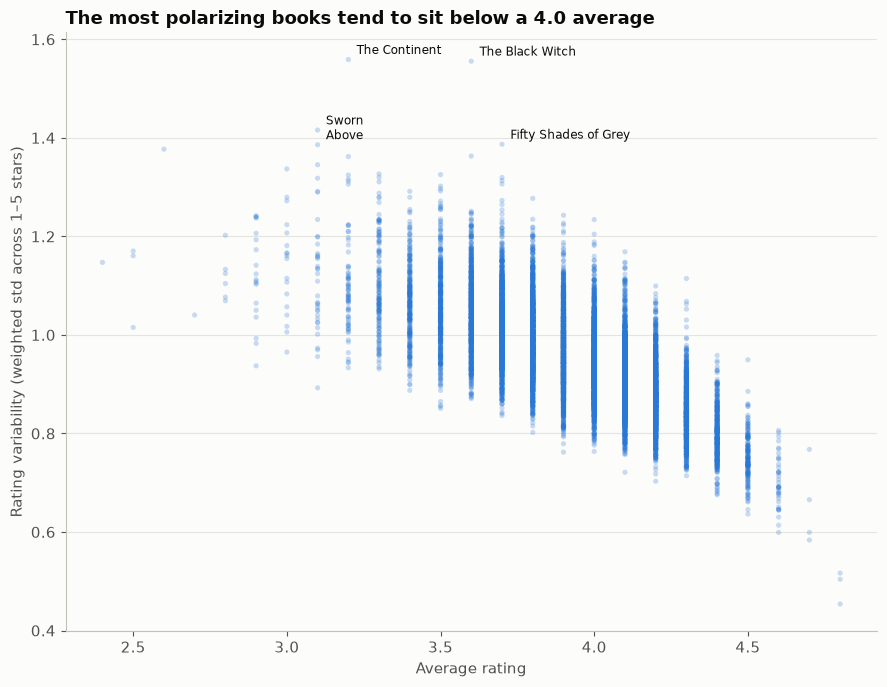

Correlation (avg_rating, rating_std): -0.708
Base: 12349 / 13525 books (ratings_count >= 1000)


In [19]:
qual = book_summary[book_summary['ratings_count'] >= 1000]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(qual['avg_rating'], qual['rating_std'], s=14, color=BLUE, alpha=0.25, edgecolors='none')

top_controversial = qual.sort_values('rating_std', ascending=False).head(5)
for _, row in top_controversial.iterrows():
    ax.annotate(row['original_title'], (row['avg_rating'], row['rating_std']),
                textcoords='offset points', xytext=(6, 4), fontsize=8.5, color='#0b0b0b')

ax.set_xlabel('Average rating')
ax.set_ylabel('Rating variability (weighted std across 1–5 stars)')
ax.set_title('The most polarizing books tend to sit below a 4.0 average',
              fontsize=13, fontweight='bold', loc='left')
ax.yaxis.grid(True)
ax.xaxis.grid(False)
strip_spines(ax, keep=('bottom', 'left'))
plt.tight_layout()
plt.show()

print('Correlation (avg_rating, rating_std):', round(qual['avg_rating'].corr(qual['rating_std']), 3))
print('Base:', len(qual), '/', len(book_summary), 'books (ratings_count >= 1000)')

**Finding:** average rating and rating variability are strongly negatively correlated (−0.708, on the 12,349-book filtered base) — books readers disagree on tend to also average lower, not just spread wider around a good score. The top 5 most polarizing books are mostly lower-profile titles (*The Continent*, *The Black Witch*, *Sworn*, *Above*), but one mainstream bestseller breaks the pattern: *Fifty Shades of Grey* sits at #4 with a 3.7 average and 1,448,482 ratings — it illustrates that high popularity and strong reader disagreement can coexist, not just a niche effect.

### 3.4 Which genres have the strongest typical engagement?

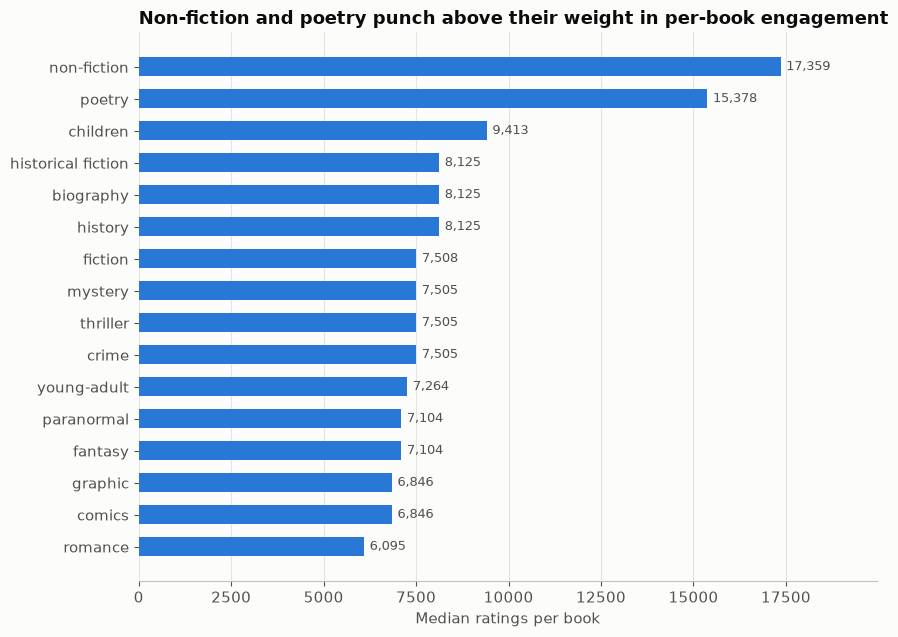

In [20]:
genre_plot = genre_summary.sort_values('median_ratings')

fig, ax = plt.subplots(figsize=(9, 6.5))
bars = ax.barh(genre_plot['genre'], genre_plot['median_ratings'], color=BLUE, height=0.6)

for bar, value in zip(bars, genre_plot['median_ratings']):
    ax.text(bar.get_width() + 150, bar.get_y() + bar.get_height() / 2, f'{value:,.0f}',
             va='center', fontsize=9, color='#52514e')

ax.set_xlabel('Median ratings per book')
ax.set_title('Non-fiction and poetry punch above their weight in per-book engagement',
              fontsize=13, fontweight='bold', loc='left')
ax.xaxis.grid(True)
ax.yaxis.grid(False)
strip_spines(ax, keep=('bottom',))
ax.set_xlim(0, genre_plot['median_ratings'].max() * 1.15)
plt.tight_layout()
plt.show()

**Finding:** `non-fiction` (median 17,359 ratings/book) and `poetry` (15,378) lead despite being the two smallest genre tags in the dataset (601 and 182 books respectively) — the typical book in these categories reaches more readers than the typical book in much larger genres like `romance` (6,095, the lowest of the 16). Note `biography`, `historical fiction`, and `history` share an identical median and book count (per the Section 2 observation) because those tags heavily co-occur on the same books in this dataset — they aren't three independent data points here. Each book contributes to multiple genre buckets (Section 1's data preparation note), so these totals are not mutually exclusive.

### 3.5 Do highly-rated authors sustain strong reception across their published works?

These 8 authors were selected because they already have the highest weighted average rating among the eligible population (the author trend filter from Section 1) — so this chart is not evidence that highly-rated authors were independently discovered to have stable ratings. It shows how their ratings vary across publication years *after* that selection. (This also reflects a refinement from the original plan, which called for the top 10 authors; 10 isn't achievable with a colorblind-safe legend palette, so this uses the top 8.)

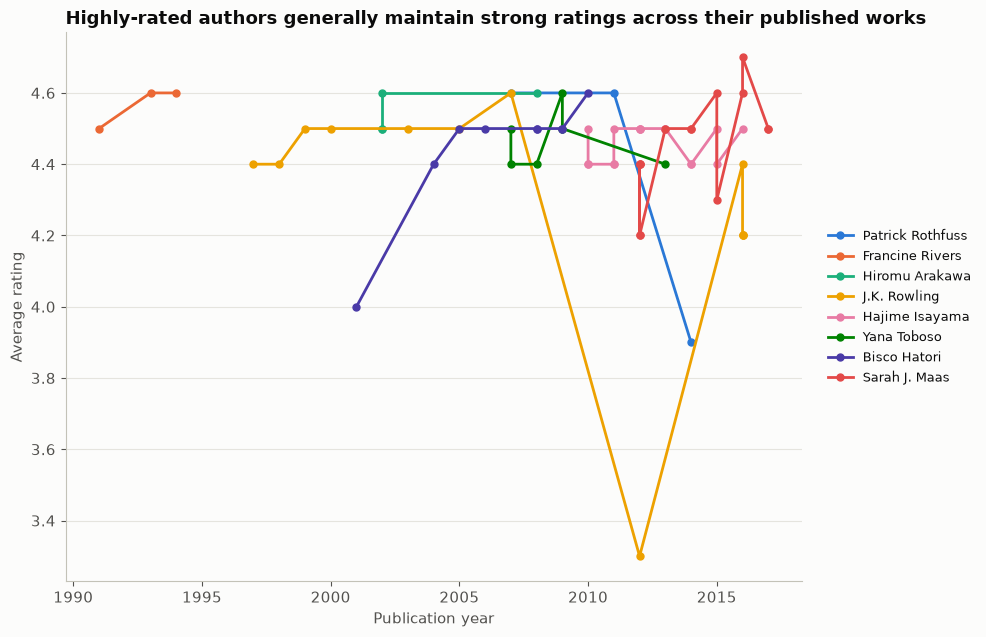

In [21]:
weighted_avg = author_year_summary.groupby('author').apply(
    lambda g: (g['avg_rating'] * g['ratings_count']).sum() / g['ratings_count'].sum(),
    include_groups=False
)
top8_authors = weighted_avg.sort_values(ascending=False).head(8)

fig, ax = plt.subplots(figsize=(10, 6.5))
for color, author in zip(CATEGORICAL, top8_authors.index):
    sub = author_year_summary[author_year_summary['author'] == author].sort_values('original_publication_year')
    ax.plot(sub['original_publication_year'], sub['avg_rating'],
            color=color, linewidth=2, marker='o', markersize=5, label=author)

ax.set_xlabel('Publication year')
ax.set_ylabel('Average rating')
ax.set_title('Highly-rated authors generally maintain strong ratings across their published works',
              fontsize=13, fontweight='bold', loc='left')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)
ax.yaxis.grid(True)
ax.xaxis.grid(False)
strip_spines(ax, keep=('bottom', 'left'))
plt.tight_layout()
plt.show()

**Finding:** 7 of the 8 authors hold a tight 4.2–4.7 band across every publication year in their qualifying catalogue. J.K. Rowling is the one exception: her Harry Potter run sits at 4.4–4.6 through 2007, then drops to 3.3 for *The Casual Vacancy* (2012) — her first adult-fiction title — before recovering to 4.2–4.4 for the Cormoran Strike novels (2016). The dip lines up with a genre/audience change, not a general decline.

## 4. Key Findings

- **Popularity concentrates hard at the top.** *The Hunger Games* (5,066,596 ratings) and *Harry Potter and the Philosopher's Stone* (4,972,886) lead by over a million ratings ahead of third place.
- **Catalogue size only partly explains author reach** (correlation 0.398) — J.K. Rowling's 12 books outpulled Stephen King's 53.
- **Rating disagreement and average rating are strongly linked** (correlation −0.708), though *Fifty Shades of Grey* shows popularity and polarization can coexist.
- **Genre size doesn't predict engagement** — non-fiction (601 books) and poetry (182 books) have higher median ratings per book than every fiction genre, including romance, the second-largest category.
- **Highly-rated authors mostly hold steady**, with J.K. Rowling's 2012 genre pivot as the clearest exception to an otherwise flat 4.2–4.7 band.

## 5. Recommendation

The patterns above point toward per-title fit mattering more than output volume: a small, well-matched catalogue can out-reach a much larger one, and per-book engagement varies substantially by genre regardless of category size. Any engagement-focused strategy should weigh title-level audience fit — including in under-examined categories like non-fiction and poetry — at least as heavily as catalogue size.